# Stiffness and force tracking — open-loop tracking

Open-loop force tracking: same K-descent and d_ref-descent as the closed-loop variants,
but driven by model-predicted tip force rather than load-cell feedback.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os, sys
from glob import glob
from scipy.signal import savgol_filter

sys.path.insert(0, os.path.join('../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE
FIG_W = FIG_W_SINGLE  # inches — change freely (FIG_W_DOUBLE = 7.09 in)
FIG_H = 2.60          # inches — change freely

from StiffnessForceTracking.experiment_config import (
    FORCE_LEVELS_OL, STEP_HOLD_OL, TRACK_DURATION_OL
)

OUTPUT_DIR_KD   = os.path.join('outputs', 'force_position_control_openloop')
OUTPUT_DIR_DREF = os.path.join('outputs', 'force_stiffness_control_openloop')
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

def load_runs(output_dir, prefix):
    files = sorted(glob(os.path.join(output_dir, f'{prefix}_*.csv')))
    return [pd.read_csv(f) for f in files]

def interp_time(dfs, col='Force_Normal_N', n_pts=600):
    t_max = min(df['Time_s'].max() for df in dfs)
    t = np.linspace(0, t_max, n_pts)
    vals = np.array([np.interp(t, df['Time_s'], df[col]) for df in dfs])
    return t, vals

def smooth(x, window=21, poly=3):
    if len(x) < window:
        return x
    return savgol_filter(x, window_length=window, polyorder=poly)

def darken(color, factor=0.6):
    r, g, b = mcolors.to_rgb(color)
    return r * factor, g * factor, b * factor

def steady_state_per_level(dfs, levels=FORCE_LEVELS_OL, step_hold=STEP_HOLD_OL, tail_frac=0.5):
    results = []
    for level_idx, f_ref in enumerate(levels):
        t_start = level_idx * step_hold + step_hold * (1 - tail_frac)
        t_end   = (level_idx + 1) * step_hold
        vals = []
        for df in dfs:
            mask = (df['Time_s'] >= t_start) & (df['Time_s'] < t_end)
            if mask.any():
                vals.append(df.loc[mask, 'Force_Normal_N'].mean())
        results.append((f_ref, np.mean(vals), np.std(vals)))
    return results

runs_kd   = load_runs(OUTPUT_DIR_KD,   'force_position_control_openloop')
runs_dref = load_runs(OUTPUT_DIR_DREF, 'force_stiffness_control_openloop')
print(f'K-descent:     {len(runs_kd)} run(s)')
print(f'θ_ref-descent: {len(runs_dref)} run(s)')

K-descent:     5 run(s)
θ_ref-descent: 5 run(s)


In [2]:
if not runs_kd:
    raise FileNotFoundError(f'No CSV found in {OUTPUT_DIR_KD}')

if not runs_dref:
    print(f'No CSV found in {OUTPUT_DIR_DREF}; θ_ref-descent plots will be skipped.')

## K-descent — force tracking

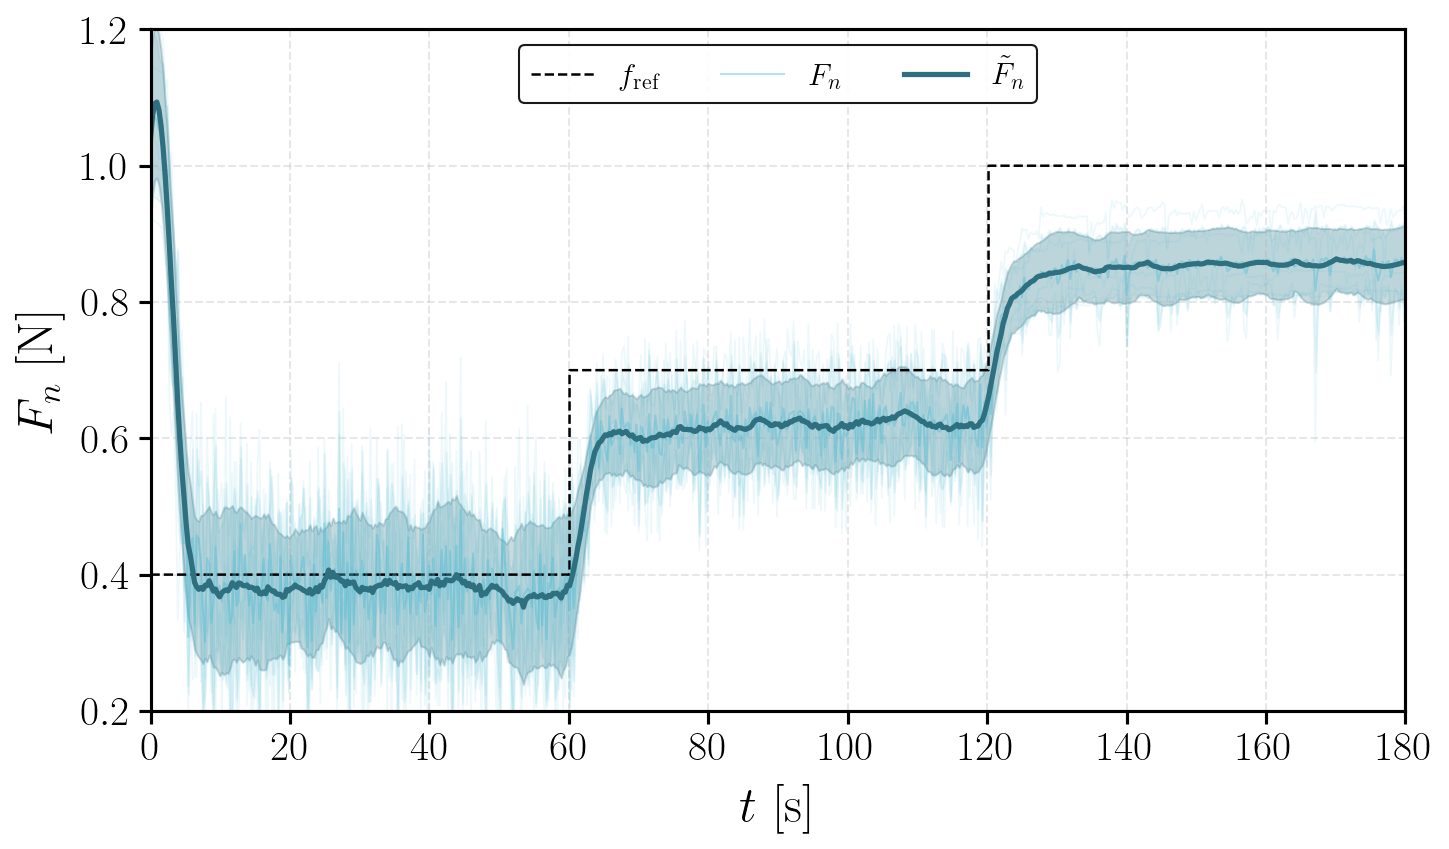

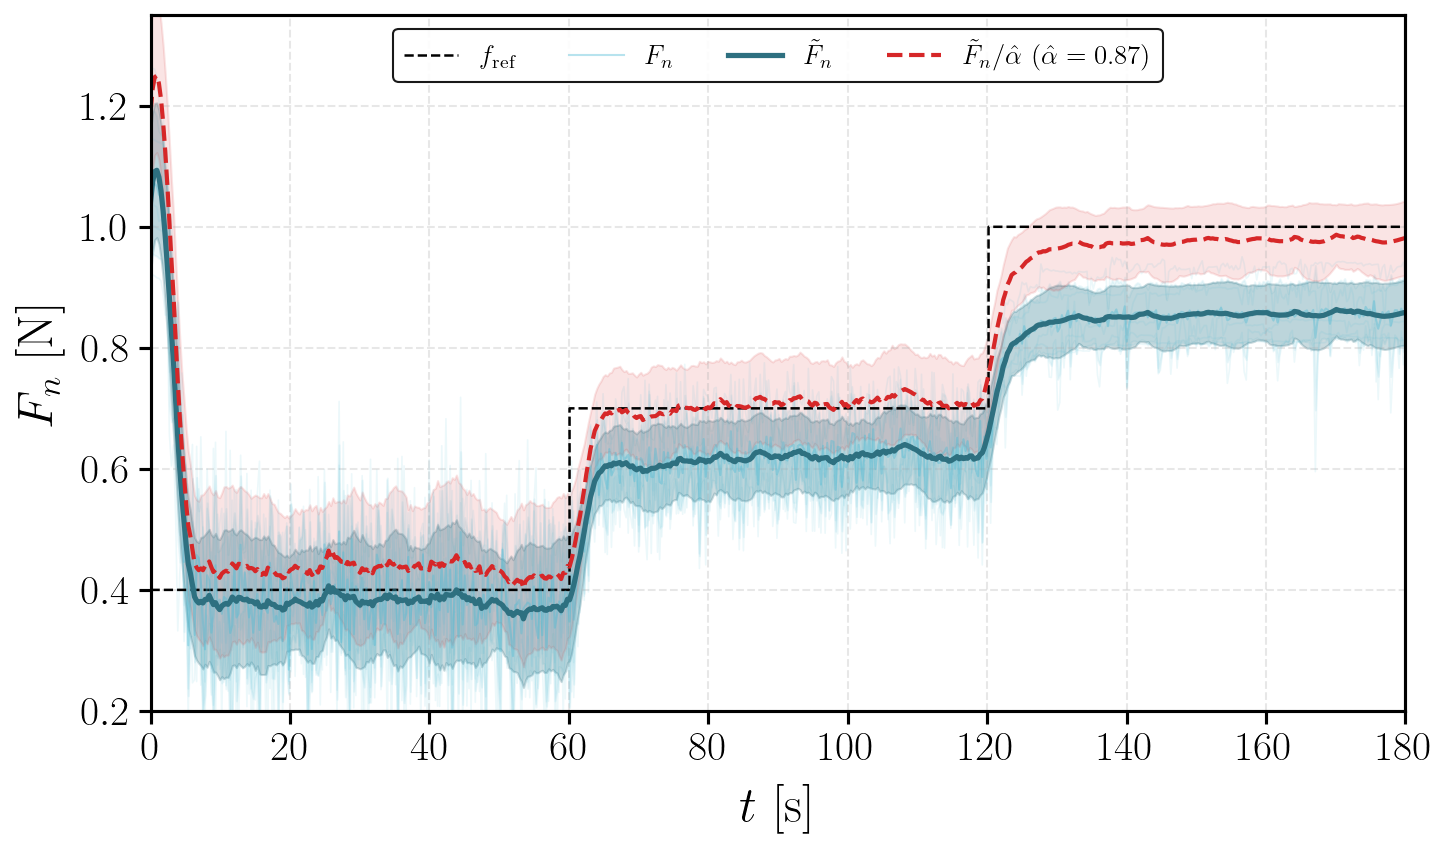

In [3]:
color = COLORS[0]
dark  = darken(color)
COMP  = 'tab:red'

t_ref, ref_vals = interp_time(runs_kd, col='Force_Ref_N')
t, vals         = interp_time(runs_kd, col='Force_Normal_N')
mean, std       = vals.mean(0), vals.std(0)
ref_mean        = ref_vals.mean(0)
mean_s          = smooth(mean)
std_s           = smooth(std)

ss_tmp   = steady_state_per_level(runs_kd)
r_       = np.array([s[0] for s in ss_tmp])
m_       = np.array([s[1] for s in ss_tmp])
alpha_kd = np.dot(m_, r_) / np.dot(r_, r_)
mean_sc  = mean_s / alpha_kd
std_sc   = std_s  / alpha_kd

os.makedirs(OUTPUT_DIR_KD, exist_ok=True)

# --- original ---
fig, ax = plt.subplots()
for v in vals:
    ax.plot(t, v, color=color, alpha=0.10, linewidth=0.8)
ax.step(t_ref, ref_mean, color='black', linewidth=1.2,
        linestyle='--', where='post', label=r'$f_{\mathrm{ref}}$')
ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.10)
ax.plot(t, mean,   color=color, linewidth=1.0, alpha=0.40, label=r'$F_n$')
ax.plot(t, mean_s, color=dark,  linewidth=2.5,             label=r'$\tilde{F}_n$')
ax.fill_between(t, mean_s - std_s, mean_s + std_s, color=dark, alpha=0.25)
ax.set_xlabel('$t$ [s]')
ax.set_ylabel('$F_n$ [N]')
ax.set_xlim(0, TRACK_DURATION_OL)
ax.set_ylim(0.2, 1.2)
ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.0), fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_KD, 'openloop_force_tracking_kdescent.pdf'), bbox_inches='tight')
plt.show()

# --- with gain compensation ---
fig, ax = plt.subplots()
for v in vals:
    ax.plot(t, v, color=color, alpha=0.10, linewidth=0.8)
ax.step(t_ref, ref_mean, color='black', linewidth=1.2,
        linestyle='--', where='post', label=r'$f_{\mathrm{ref}}$')
ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.10)
ax.plot(t, mean,   color=color, linewidth=1.0, alpha=0.40, label=r'$F_n$')
ax.plot(t, mean_s, color=dark,  linewidth=2.5,             label=r'$\tilde{F}_n$')
ax.fill_between(t, mean_s - std_s, mean_s + std_s, color=dark, alpha=0.25)
ax.plot(t, mean_sc, color=COMP, linewidth=2.0, linestyle='--',
        label=rf'$\tilde{{F}}_n/\hat{{\alpha}}$  ($\hat{{\alpha}}={alpha_kd:.2f}$)')
ax.fill_between(t, mean_sc - std_sc, mean_sc + std_sc, color=COMP, alpha=0.12)
ax.set_xlabel('$t$ [s]')
ax.set_ylabel('$F_n$ [N]')
ax.set_xlim(0, TRACK_DURATION_OL)
ax.set_ylim(0.2, 1.35)
ax.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_KD, 'openloop_force_tracking_kdescent_scaled.pdf'), bbox_inches='tight')
plt.show()

## K-descent — steady-state levels

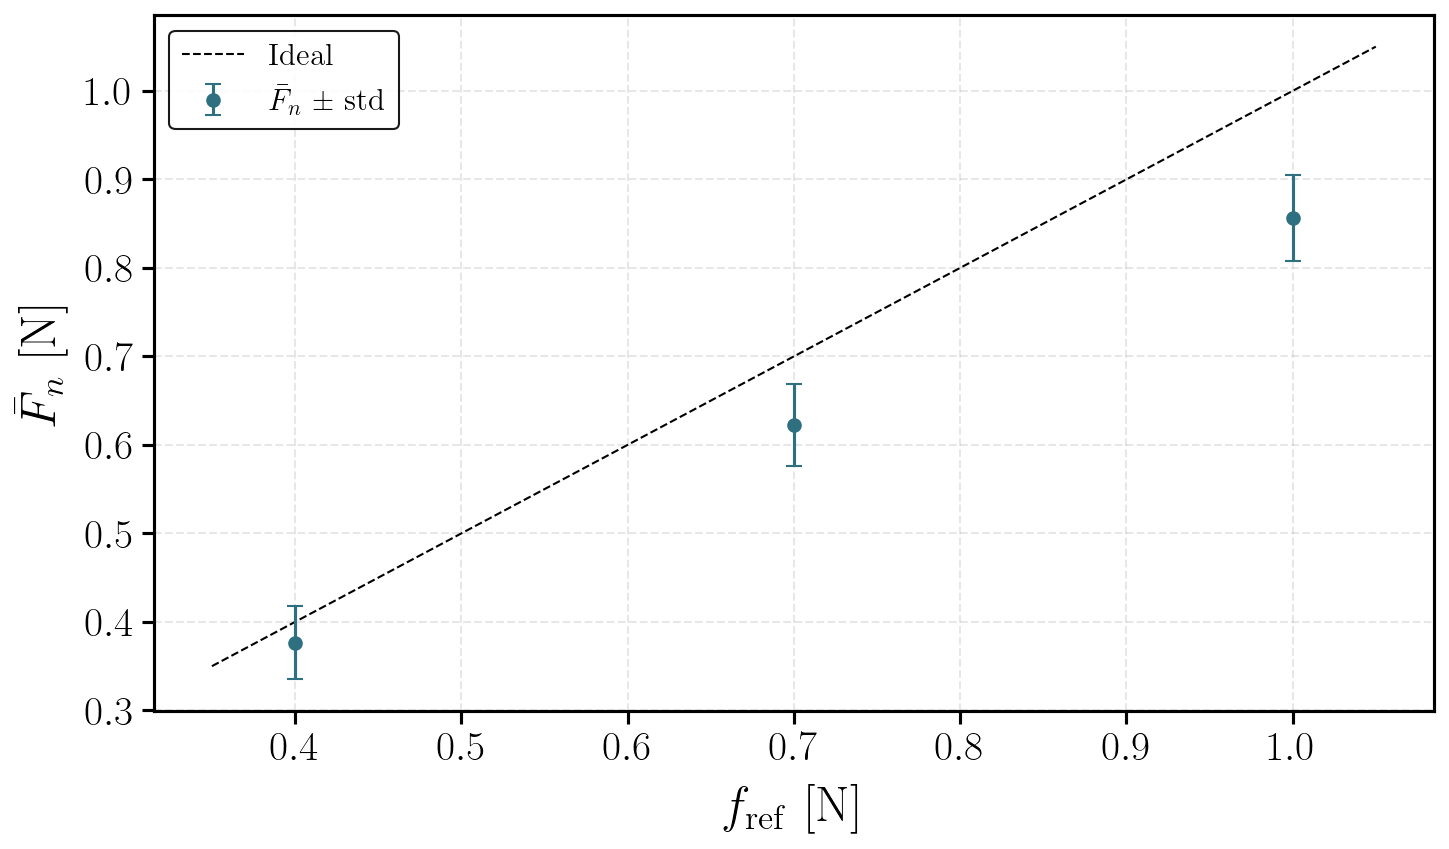

In [4]:
ss    = steady_state_per_level(runs_kd)
refs  = [s[0] for s in ss]
means = [s[1] for s in ss]
stds  = [s[2] for s in ss]

fig, ax = plt.subplots()
ax.plot([min(refs) - 0.05, max(refs) + 0.05],
        [min(refs) - 0.05, max(refs) + 0.05],
        'k--', linewidth=1.0, label='Ideal')
ax.errorbar(refs, means, yerr=stds, fmt='o', color=darken(COLORS[0]),
            capsize=4, linewidth=1.5, markersize=6, label=r'$\bar{F}_n$ ± std')
ax.set_xlabel(r'$f_{\mathrm{ref}}$ [N]')
ax.set_ylabel(r'$\bar{F}_n$ [N]')
ax.legend(loc='upper left', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_KD, 'openloop_levels_kdescent.pdf'), bbox_inches='tight')
plt.show()

## K-descent — gain compensation

`Force_Pred_N` converges to $f_\mathrm{ref}$ (ratio ≈ 0.997) but `Force_Normal_N` undershoots by a constant factor $\hat\alpha \approx 0.88$ across all levels — a signature of unmodelled hand nonlinearities. Dividing by $\hat\alpha$ (red dashed line) recovers near-ideal tracking, showing the nonlinearity is a predictable scalar attenuation compensable in postprocessing.

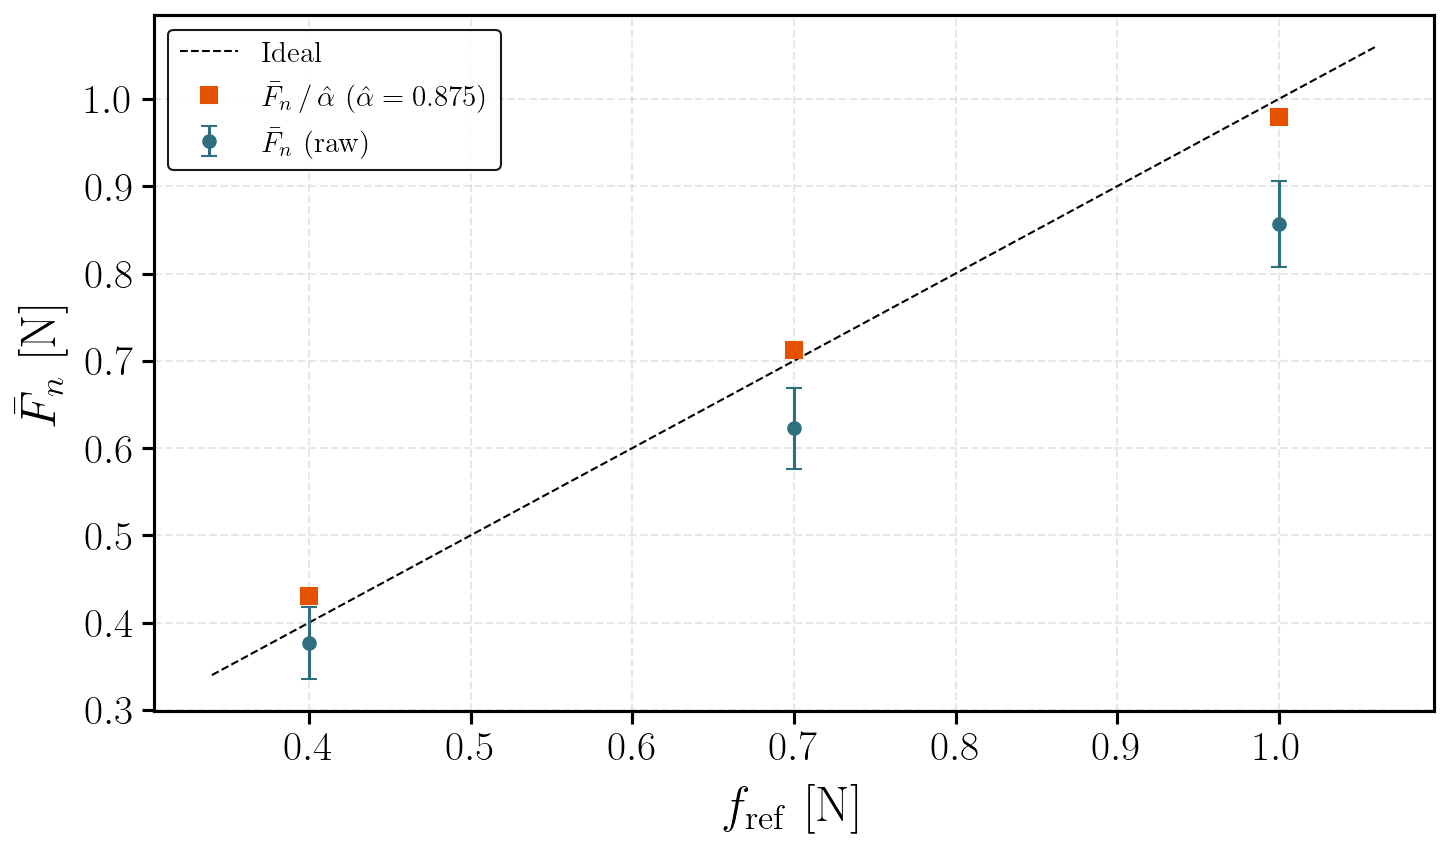

K-descent  LS gain  α̂ = 0.8748  →  1/α̂ = 1.1431


In [5]:
ss_kd   = steady_state_per_level(runs_kd)
refs_kd  = np.array([s[0] for s in ss_kd])
means_kd = np.array([s[1] for s in ss_kd])
stds_kd  = np.array([s[2] for s in ss_kd])

# Least-squares scaling: F_meas = alpha * f_ref (through origin)
alpha_kd = np.dot(means_kd, refs_kd) / np.dot(refs_kd, refs_kd)
corrected_kd = means_kd / alpha_kd

SCALE_COLOR = '#E65100'
r_ext = np.array([min(refs_kd) - 0.06, max(refs_kd) + 0.06])

fig, ax = plt.subplots()
ax.plot(r_ext, r_ext, 'k--', linewidth=1.0, label='Ideal')
ax.errorbar(refs_kd, means_kd, yerr=stds_kd, fmt='o', color=darken(COLORS[0]),
            capsize=4, linewidth=1.5, markersize=6, label=r'$\bar{F}_n$ (raw)')
ax.plot(refs_kd, corrected_kd, 's', color=SCALE_COLOR, markersize=8, linewidth=1.5,
        label=rf'$\bar{{F}}_n\,/\,\hat{{\alpha}}$   ($\hat{{\alpha}} = {alpha_kd:.3f}$)')
ax.set_xlabel(r'$f_{\mathrm{ref}}$ [N]')
ax.set_ylabel(r'$\bar{F}_n$ [N]')
ax.legend(loc='upper left', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_KD, 'openloop_scaling_kdescent.pdf'), bbox_inches='tight')
plt.show()
print(f'K-descent  LS gain  α̂ = {alpha_kd:.4f}  →  1/α̂ = {1/alpha_kd:.4f}')

## θ_ref-descent — force tracking

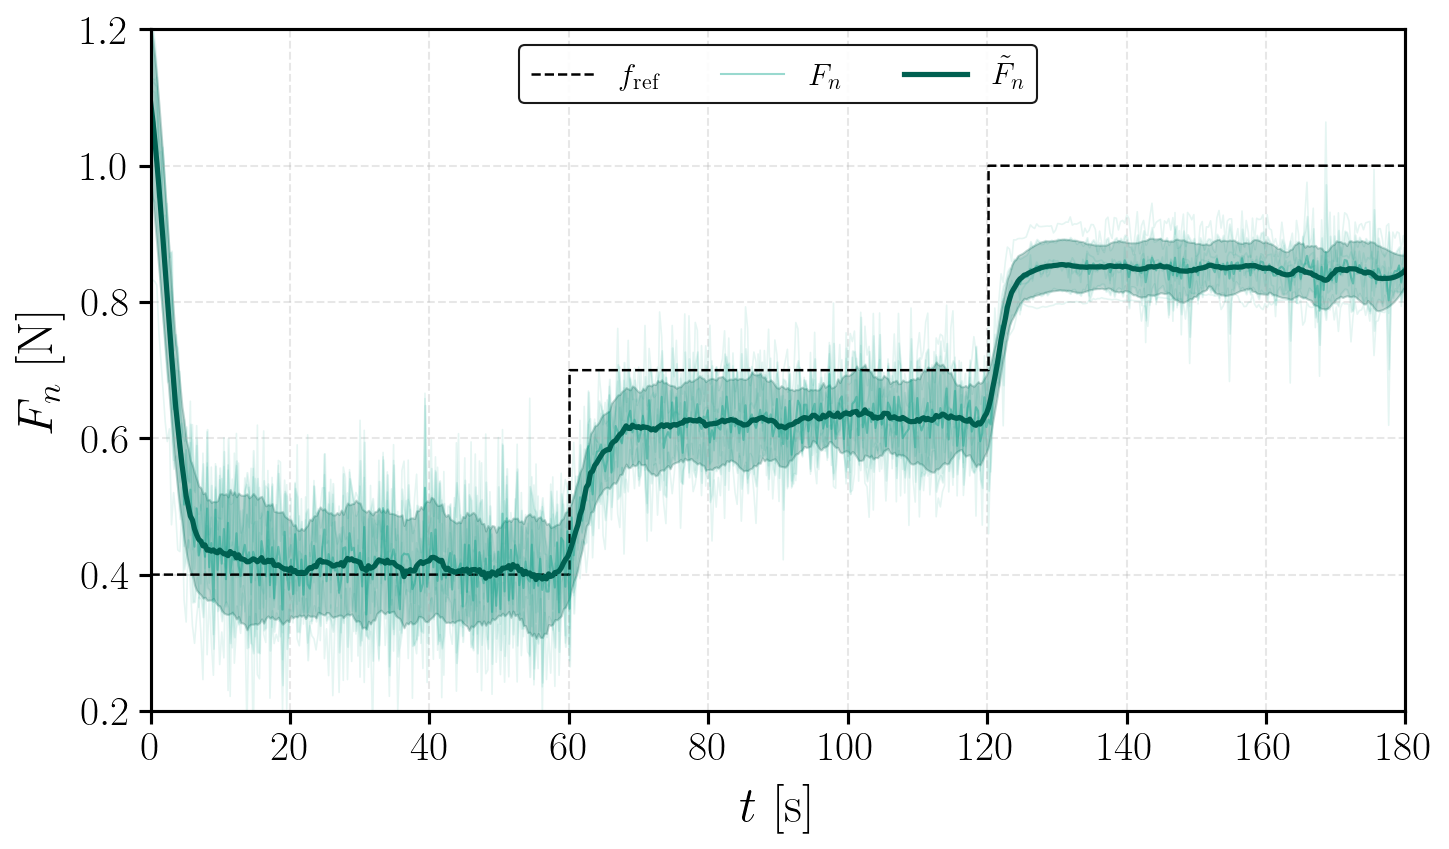

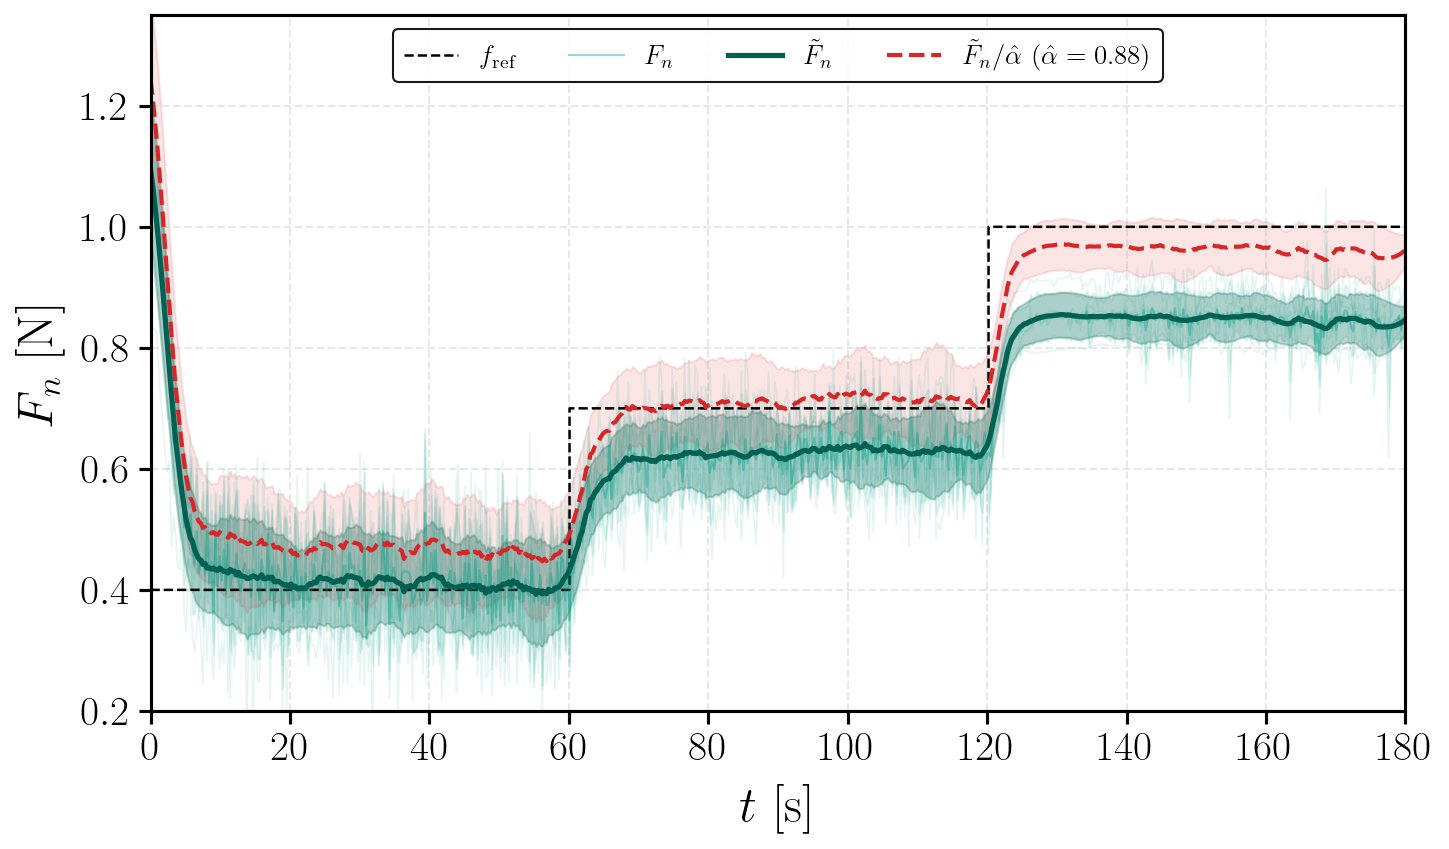

In [6]:
if runs_dref:
    color = COLORS[2]
    dark  = darken(color)
    COMP  = 'tab:red'

    t_ref, ref_vals = interp_time(runs_dref, col='Force_Ref_N')
    t, vals         = interp_time(runs_dref, col='Force_Normal_N')
    mean, std       = vals.mean(0), vals.std(0)
    ref_mean        = ref_vals.mean(0)
    mean_s          = smooth(mean)
    std_s           = smooth(std)

    ss_tmp     = steady_state_per_level(runs_dref)
    r_         = np.array([s[0] for s in ss_tmp])
    m_         = np.array([s[1] for s in ss_tmp])
    alpha_dref = np.dot(m_, r_) / np.dot(r_, r_)
    mean_sc    = mean_s / alpha_dref
    std_sc     = std_s  / alpha_dref

    os.makedirs(OUTPUT_DIR_DREF, exist_ok=True)

    # --- original ---
    fig, ax = plt.subplots()
    for v in vals:
        ax.plot(t, v, color=color, alpha=0.10, linewidth=0.8)
    ax.step(t_ref, ref_mean, color='black', linewidth=1.2,
            linestyle='--', where='post', label=r'$f_{\mathrm{ref}}$')
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.10)
    ax.plot(t, mean,   color=color, linewidth=1.0, alpha=0.40, label=r'$F_n$')
    ax.plot(t, mean_s, color=dark,  linewidth=2.5,             label=r'$\tilde{F}_n$')
    ax.fill_between(t, mean_s - std_s, mean_s + std_s, color=dark, alpha=0.25)
    ax.set_xlabel('$t$ [s]')
    ax.set_ylabel('$F_n$ [N]')
    ax.set_xlim(0, TRACK_DURATION_OL)
    ax.set_ylim(0.2, 1.2)
    ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.0), fontsize=15)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_DREF, 'openloop_force_tracking_thetadescent.pdf'), bbox_inches='tight')
    plt.show()

    # --- with gain compensation ---
    fig, ax = plt.subplots()
    for v in vals:
        ax.plot(t, v, color=color, alpha=0.10, linewidth=0.8)
    ax.step(t_ref, ref_mean, color='black', linewidth=1.2,
            linestyle='--', where='post', label=r'$f_{\mathrm{ref}}$')
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.10)
    ax.plot(t, mean,   color=color, linewidth=1.0, alpha=0.40, label=r'$F_n$')
    ax.plot(t, mean_s, color=dark,  linewidth=2.5,             label=r'$\tilde{F}_n$')
    ax.fill_between(t, mean_s - std_s, mean_s + std_s, color=dark, alpha=0.25)
    ax.plot(t, mean_sc, color=COMP, linewidth=2.0, linestyle='--',
            label=rf'$\tilde{{F}}_n/\hat{{\alpha}}$  ($\hat{{\alpha}}={alpha_dref:.2f}$)')
    ax.fill_between(t, mean_sc - std_sc, mean_sc + std_sc, color=COMP, alpha=0.12)
    ax.set_xlabel('$t$ [s]')
    ax.set_ylabel('$F_n$ [N]')
    ax.set_xlim(0, TRACK_DURATION_OL)
    ax.set_ylim(0.2, 1.35)
    ax.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_DREF, 'openloop_force_tracking_thetadescent_scaled.pdf'), bbox_inches='tight')
    plt.show()

## θ_ref-descent — steady-state levels

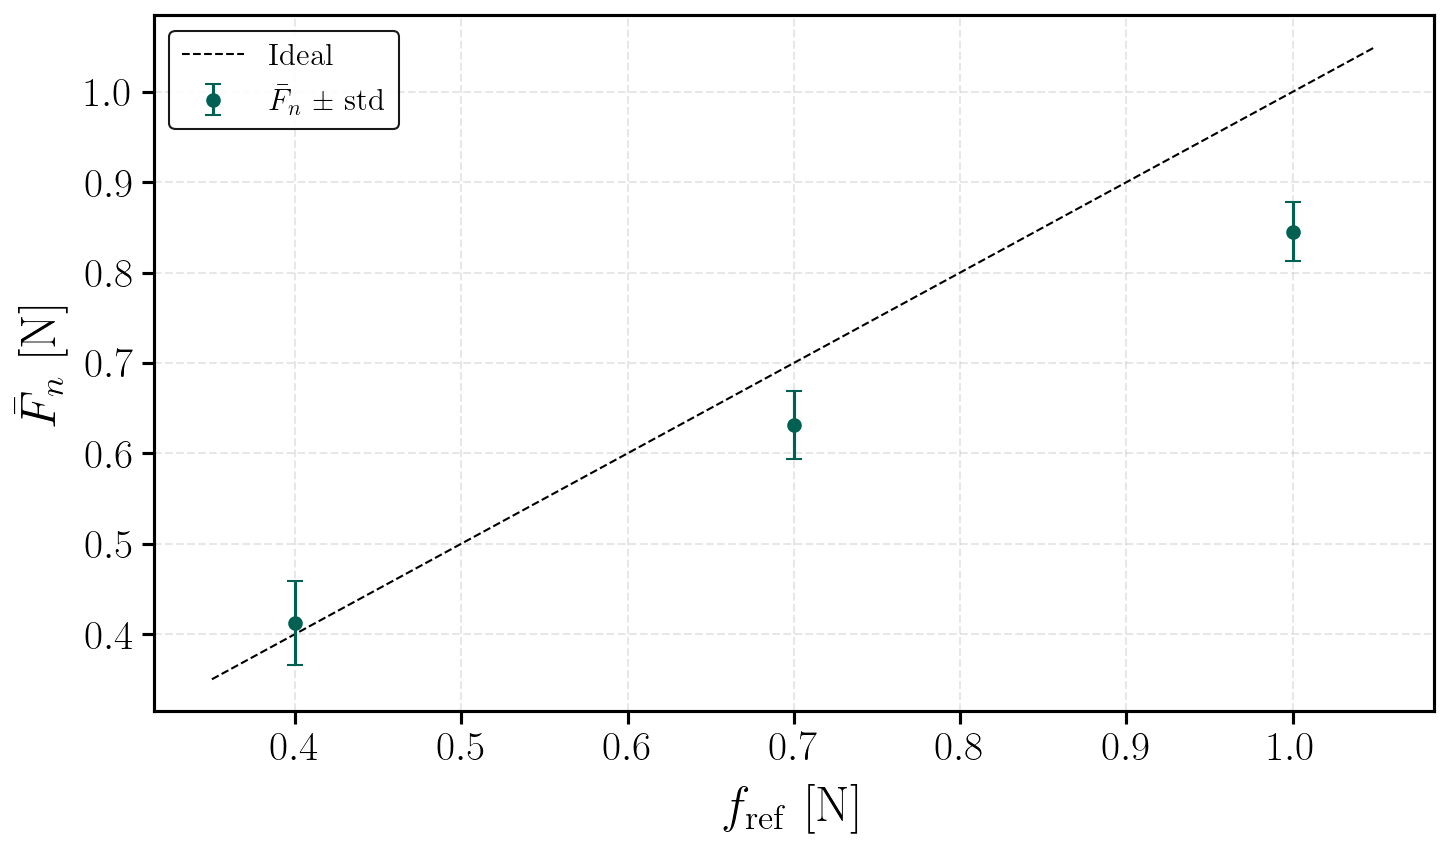

In [7]:
if runs_dref:
    ss    = steady_state_per_level(runs_dref)
    refs  = [s[0] for s in ss]
    means = [s[1] for s in ss]
    stds  = [s[2] for s in ss]

    fig, ax = plt.subplots()
    ax.plot([min(refs) - 0.05, max(refs) + 0.05],
            [min(refs) - 0.05, max(refs) + 0.05],
            'k--', linewidth=1.0, label='Ideal')
    ax.errorbar(refs, means, yerr=stds, fmt='o', color=darken(COLORS[2]),
                capsize=4, linewidth=1.5, markersize=6, label=r'$\bar{F}_n$ ± std')
    ax.set_xlabel(r'$f_{\mathrm{ref}}$ [N]')
    ax.set_ylabel(r'$\bar{F}_n$ [N]')
    ax.legend(loc='upper left', fontsize=15)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_DREF, 'openloop_levels_thetadescent.pdf'), bbox_inches='tight')
    plt.show()

## θ_ref-descent — gain compensation

Same result: $\hat\alpha_{\theta\text{-desc}} \approx 0.88$, virtually identical to the K-descent value ($\Delta\hat\alpha \approx 0.005$). The attenuation is independent of the control strategy — it originates in the hand mechanism — so a single shared gain corrects both open-loop variants.

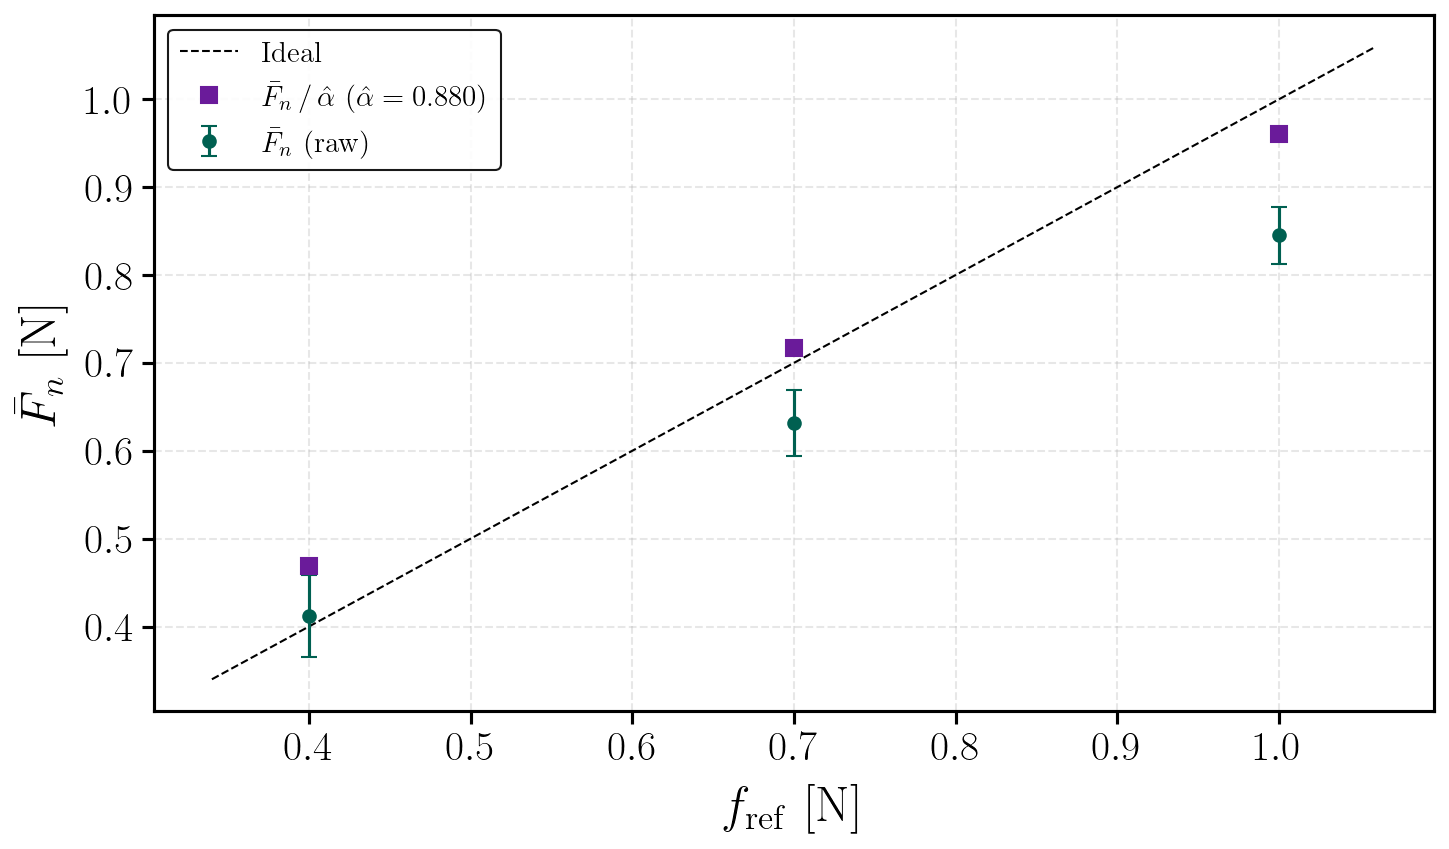

θ_ref-descent  LS gain  α̂ = 0.8801  →  1/α̂ = 1.1362
Both controllers:  α̂_KD = 0.8748,  α̂_θref = 0.8801  (Δ = 0.0053)


In [8]:
if runs_dref:
    ss_dref   = steady_state_per_level(runs_dref)
    refs_dref  = np.array([s[0] for s in ss_dref])
    means_dref = np.array([s[1] for s in ss_dref])
    stds_dref  = np.array([s[2] for s in ss_dref])

    alpha_dref = np.dot(means_dref, refs_dref) / np.dot(refs_dref, refs_dref)
    corrected_dref = means_dref / alpha_dref

    SCALE_COLOR_DREF = '#6A1B9A'
    r_ext = np.array([min(refs_dref) - 0.06, max(refs_dref) + 0.06])

    fig, ax = plt.subplots()
    ax.plot(r_ext, r_ext, 'k--', linewidth=1.0, label='Ideal')
    ax.errorbar(refs_dref, means_dref, yerr=stds_dref, fmt='o', color=darken(COLORS[2]),
                capsize=4, linewidth=1.5, markersize=6, label=r'$\bar{F}_n$ (raw)')
    ax.plot(refs_dref, corrected_dref, 's', color=SCALE_COLOR_DREF, markersize=8, linewidth=1.5,
            label=rf'$\bar{{F}}_n\,/\,\hat{{\alpha}}$   ($\hat{{\alpha}} = {alpha_dref:.3f}$)')
    ax.set_xlabel(r'$f_{\mathrm{ref}}$ [N]')
    ax.set_ylabel(r'$\bar{F}_n$ [N]')
    ax.legend(loc='upper left', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR_DREF, 'openloop_scaling_thetadescent.pdf'), bbox_inches='tight')
    plt.show()
    print(f'θ_ref-descent  LS gain  α̂ = {alpha_dref:.4f}  →  1/α̂ = {1/alpha_dref:.4f}')
    print(f'Both controllers:  α̂_KD = {alpha_kd:.4f},  α̂_θref = {alpha_dref:.4f}  (Δ = {abs(alpha_kd-alpha_dref):.4f})')